# 📊 Análise Exploratória de Dados (EDA) — Telco Customer Churn

**Objetivo**: Realizar uma análise completa do dataset de churn de telecomunicações, avaliando volume, qualidade, distribuições e data readiness para modelagem ML.

**Dataset**: Telco Customer Churn (IBM)  
**Referência**: Ciclo de Vida, Aula 01 — Etapa 1 do Tech Challenge

---

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import hashlib
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

SEED = 42
np.random.seed(SEED)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Carregamento e Versionamento do Dataset

In [2]:
DATA_PATH = Path('../../data/Telco-Customer-Churn.csv')

df = pd.read_csv(DATA_PATH)

# Dataset versioning via SHA256
with open(DATA_PATH, 'rb') as f:
    dataset_hash = hashlib.sha256(f.read()).hexdigest()

print(f'Dataset loaded: {DATA_PATH.name}')
print(f'Dataset SHA256: {dataset_hash[:16]}...')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded: Telco-Customer-Churn.csv
Dataset SHA256: 88be4b93fbe0cc83...
Shape: 7043 rows × 21 columns


## 2. Análise de Volume

Avaliação do tamanho do dataset, tipos de dados e consumo de memória.

In [3]:
print('='*60)
print('ANÁLISE DE VOLUME')
print('='*60)
print(f'\nTotal de registros: {df.shape[0]:,}')
print(f'Total de features:  {df.shape[1]}')
print(f'Memória utilizada:  {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'\n--- Tipos de dados ---')
print(df.dtypes.value_counts())
print(f'\n--- Info do DataFrame ---')
df.info()

ANÁLISE DE VOLUME

Total de registros: 7,043
Total de features:  21
Memória utilizada:  6.82 MB

--- Tipos de dados ---
object     18
int64       2
float64     1
Name: count, dtype: int64

--- Info do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport    

In [4]:
print('--- Primeiras 5 linhas ---')
df.head()

--- Primeiras 5 linhas ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print('--- Últimas 5 linhas ---')
df.tail()

--- Últimas 5 linhas ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
print('--- Amostra aleatória (5 linhas) ---')
df.sample(5, random_state=SEED)

--- Amostra aleatória (5 linhas) ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


## 3. Análise de Qualidade dos Dados

Identificação de valores ausentes, duplicatas e inconsistências.

In [7]:
print('='*60)
print('ANÁLISE DE QUALIDADE')
print('='*60)

# Valores nulos
null_count = df.isnull().sum()
null_pct = (null_count / len(df) * 100).round(2)
null_report = pd.DataFrame({
    'Nulos': null_count,
    'Percentual (%)': null_pct
}).sort_values('Percentual (%)', ascending=False)

print('\n--- Valores Nulos ---')
print(null_report[null_report['Nulos'] > 0] if null_report['Nulos'].sum() > 0 else 'Nenhum valor nulo encontrado.')

ANÁLISE DE QUALIDADE

--- Valores Nulos ---
Nenhum valor nulo encontrado.


In [8]:
# Duplicatas
duplicates = df.duplicated().sum()
print(f'\n--- Duplicatas ---')
print(f'Total de linhas duplicadas: {duplicates}')
print(f'CustomerIDs duplicados: {df["customerID"].duplicated().sum()}')


--- Duplicatas ---
Total de linhas duplicadas: 0
CustomerIDs duplicados: 0


In [9]:
# Inconsistência em TotalCharges (armazenado como string com espaços em branco)
print('\n--- Inconsistências em TotalCharges ---')
blank_total_charges = df[df['TotalCharges'] == ' ']
print(f'Registros com TotalCharges em branco: {len(blank_total_charges)}')
if len(blank_total_charges) > 0:
    print(f'\nCaracterísticas desses registros:')
    print(blank_total_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])
    print(f'\nObservação: Todos têm tenure=0, indicando clientes recém-cadastrados.')


--- Inconsistências em TotalCharges ---
Registros com TotalCharges em branco: 11

Características desses registros:
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No

Observação: Todos têm tenure=0, indicando clientes recém-cadastrados.


In [10]:
# Corrigir TotalCharges para numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'Após conversão — NaN em TotalCharges: {df["TotalCharges"].isna().sum()}')
print(f'Tipo de TotalCharges: {df["TotalCharges"].dtype}')

Após conversão — NaN em TotalCharges: 11


Tipo de TotalCharges: float64


## 4. Estatísticas Descritivas

In [11]:
print('--- Estatísticas das variáveis numéricas ---')
df.describe()

--- Estatísticas das variáveis numéricas ---


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
print('--- Estatísticas das variáveis categóricas ---')
df.describe(include='object')

--- Estatísticas das variáveis categóricas ---


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


## 5. Análise da Variável Target (Churn)

Avaliação do desbalanceamento de classes.

--- Distribuição do Target (Churn) ---


       Count  Percentual (%)
Churn                       
No      5174           73.46
Yes     1869           26.54

Ratio (No/Yes): 2.77:1
Desbalanceamento: A classe minoritária (Yes) representa 26.5% dos dados.


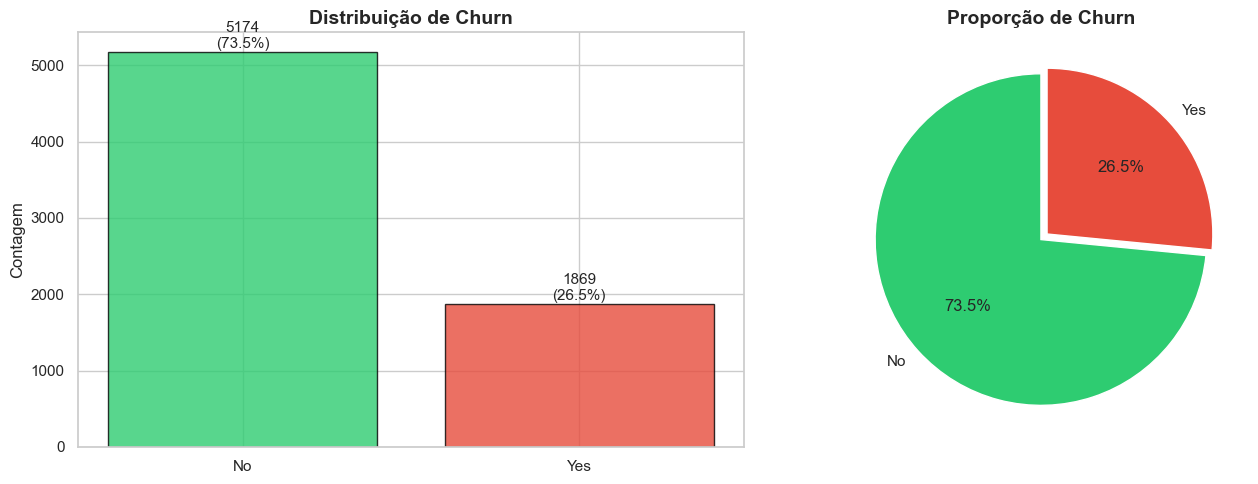

In [13]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('--- Distribuição do Target (Churn) ---')
print(pd.DataFrame({'Count': churn_counts, 'Percentual (%)': churn_pct.round(2)}))
print(f'\nRatio (No/Yes): {churn_counts["No"]/churn_counts["Yes"]:.2f}:1')
print(f'Desbalanceamento: A classe minoritária (Yes) representa {churn_pct["Yes"]:.1f}% dos dados.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Distribuição de Churn', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Contagem')
for i, (val, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, val + 50, f'{val}\n({pct:.1f}%)', ha='center', fontsize=11)

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05))
axes[1].set_title('Proporção de Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Distribuição das Features Numéricas

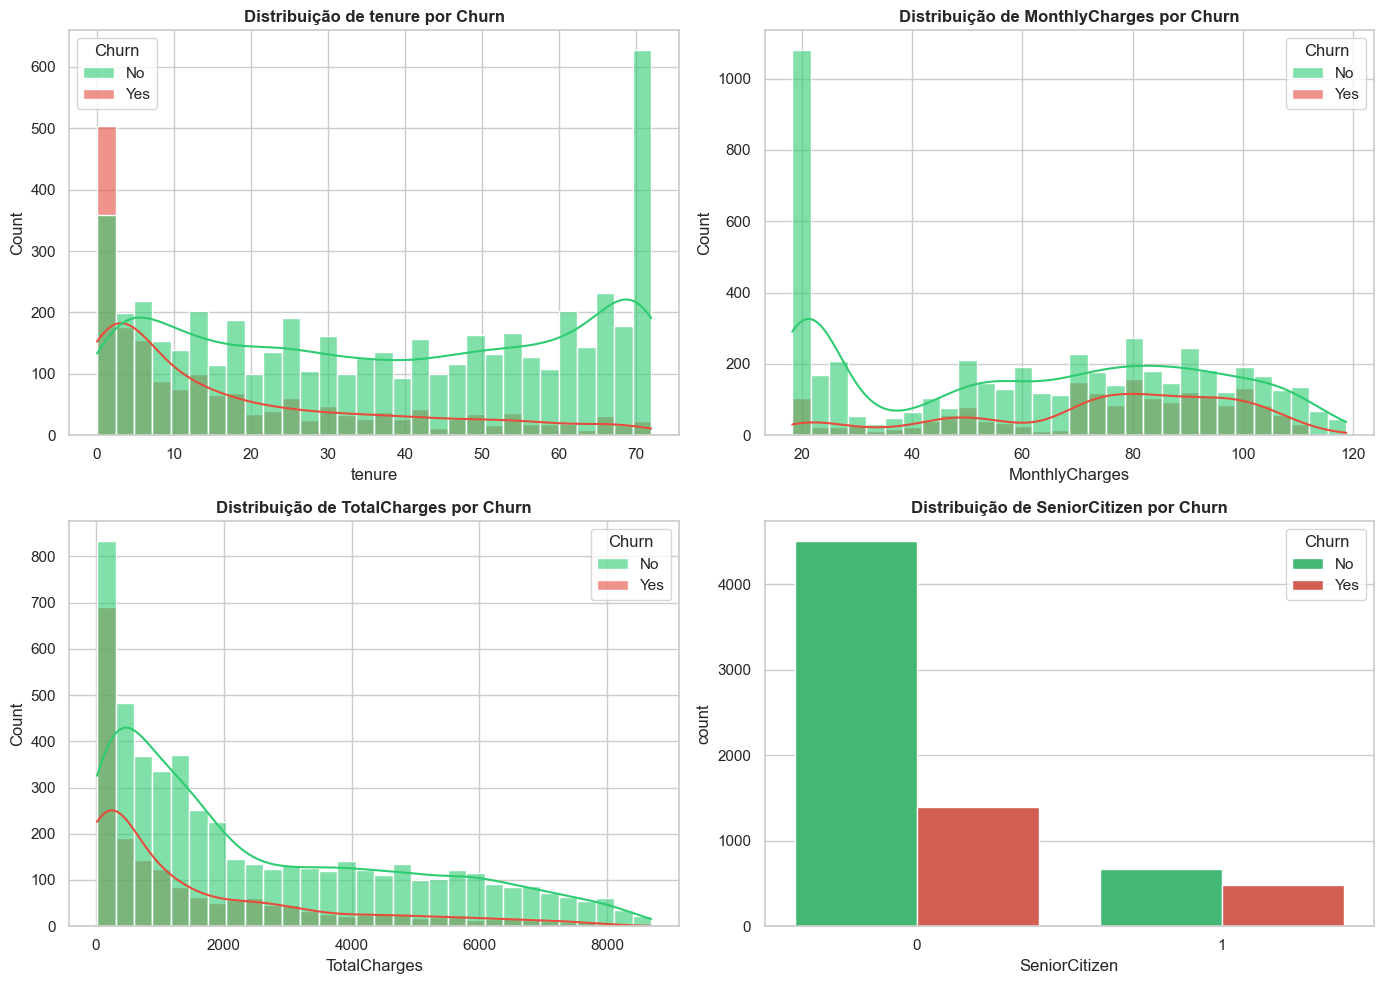

In [14]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if col == 'SeniorCitizen':
        sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette=colors)
        axes[i].set_title(f'Distribuição de {col} por Churn', fontsize=12, fontweight='bold')
    else:
        sns.histplot(data=df, x=col, hue='Churn', kde=True, bins=30, ax=axes[i], palette=colors, alpha=0.6)
        axes[i].set_title(f'Distribuição de {col} por Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Insights das Features Numéricas

- **tenure**: Clientes com churn tendem a ter tenure baixo (< 12 meses). Clientes com alta permanência raramente cancelam.
- **MonthlyCharges**: Clientes com churn têm cobrança mensal mais alta (concentração em R$70-100).
- **TotalCharges**: Churns concentram-se em valores baixos de TotalCharges (correlação com tenure baixo).
- **SeniorCitizen**: Proporcionalmente, idosos têm taxa de churn maior.

## 7. Distribuição das Features Categóricas

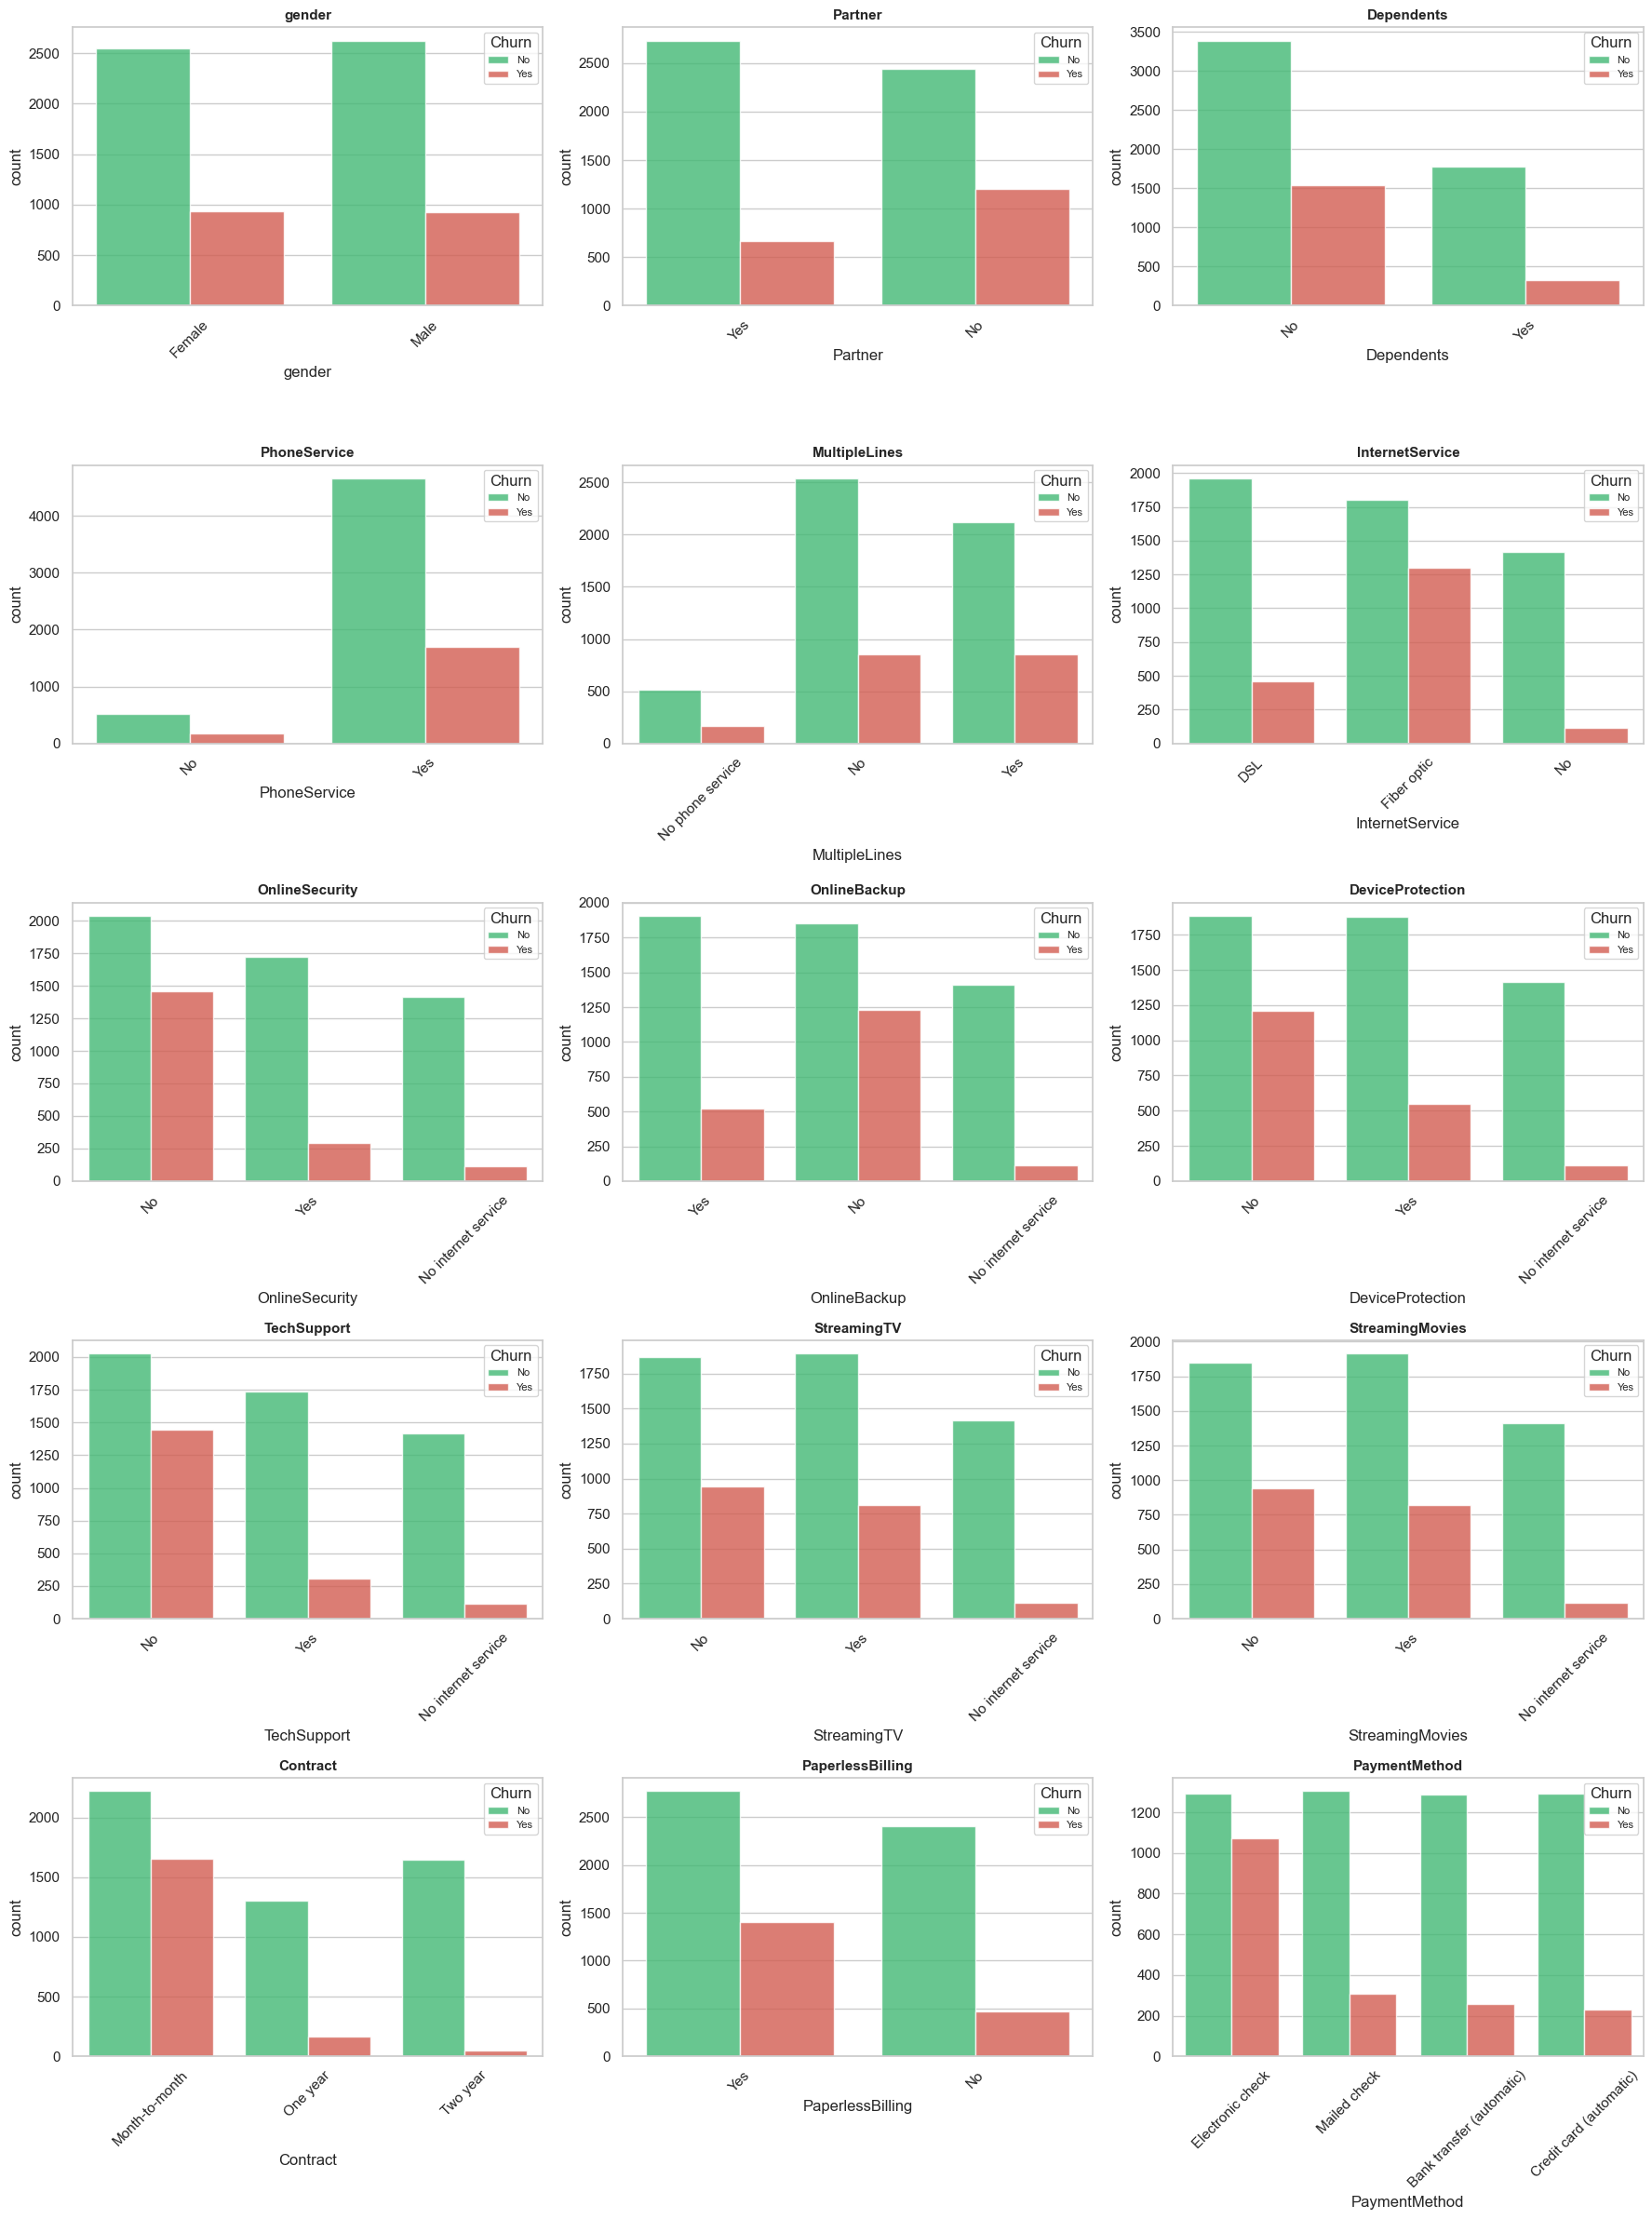

In [15]:
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(5, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette=colors, alpha=0.8)
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Churn', fontsize=8)

plt.tight_layout()
plt.show()

### Insights das Features Categóricas

- **Contract**: Contratos mês-a-mês têm taxa de churn **drasticamente** maior. Contratos de 1-2 anos são mais estáveis.
- **InternetService**: Fibra óptica tem maior taxa de churn (possível insatisfação com qualidade vs. preço).
- **OnlineSecurity / TechSupport**: Ausência desses serviços correlaciona-se com maior churn.
- **PaymentMethod**: Cheque eletrônico tem a maior taxa de churn.
- **gender**: Sem diferença significativa entre gêneros.
- **PaperlessBilling**: Clientes com fatura digital têm maior churn.

## 8. Análise de Correlação

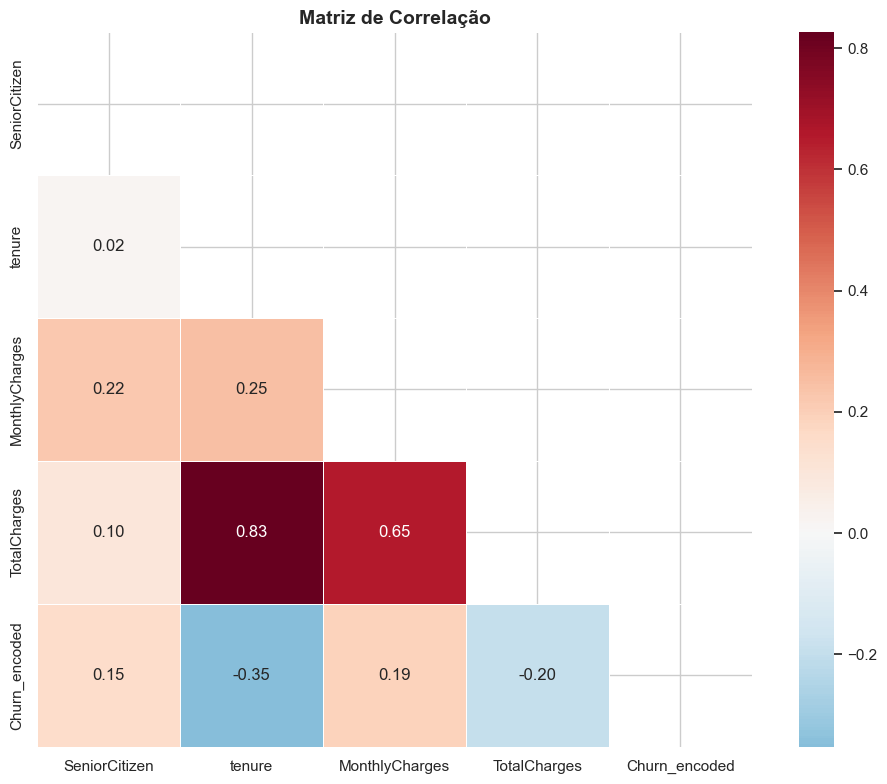


--- Correlação com Churn ---
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn_encoded, dtype: float64


In [16]:
# Encode target for correlation
df_corr = df.copy()
df_corr['Churn_encoded'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

numeric_for_corr = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[numeric_for_corr].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True)
plt.title('Matriz de Correlação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n--- Correlação com Churn ---')
churn_corr = corr_matrix['Churn_encoded'].drop('Churn_encoded').sort_values(ascending=False)
print(churn_corr)

### Insights de Correlação

- **tenure** tem correlação **negativa** forte com churn (~-0.35): clientes mais antigos cancelam menos.
- **MonthlyCharges** tem correlação **positiva** com churn (~0.19): cobranças maiores associadas a mais cancelamento.
- **TotalCharges** tem correlação **negativa** fraca com churn: reflexo da correlação tenure-TotalCharges.
- **tenure × TotalCharges** têm correlação **forte** entre si (~0.83), o que é esperado.

## 9. Análise de Outliers

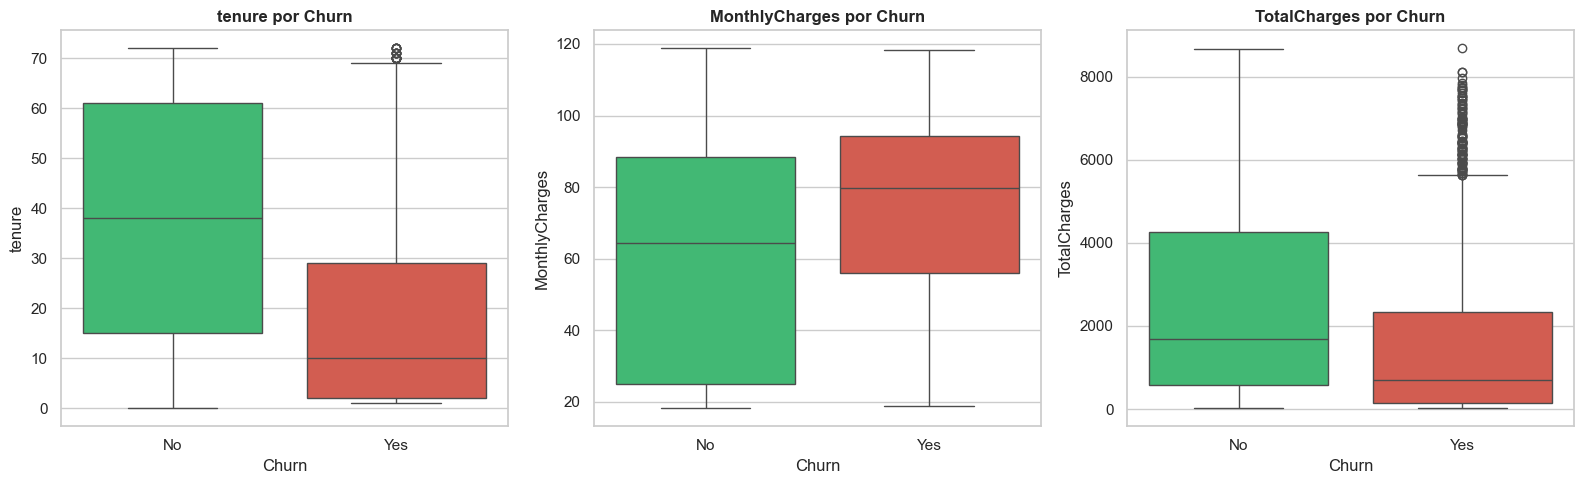


--- Outliers (|Z-score| > 3) ---
tenure: 0 outliers (0.00%)
MonthlyCharges: 0 outliers (0.00%)
TotalCharges: 0 outliers (0.00%)


In [17]:
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df, y=col, x='Churn', ax=axes[i], palette=colors)
    axes[i].set_title(f'{col} por Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Z-score outlier detection
from scipy import stats
print('\n--- Outliers (|Z-score| > 3) ---')
for col in continuous_cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    outliers = (z > 3).sum()
    print(f'{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)')

## 10. Churn Rate por Segmento

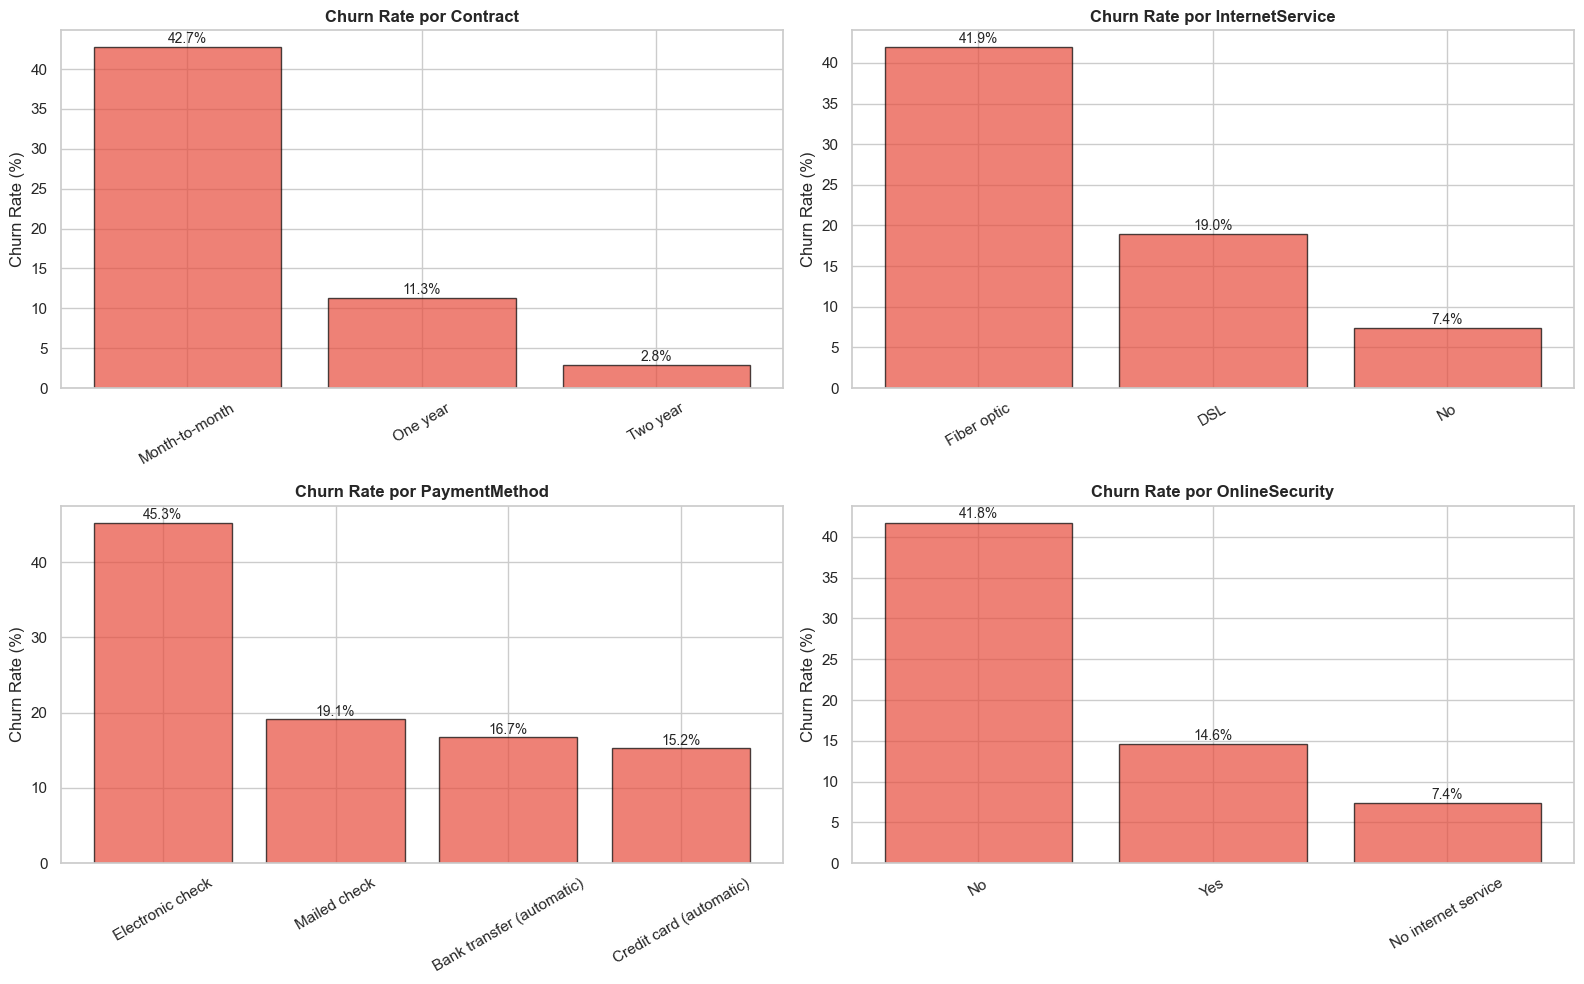

In [18]:
key_segments = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_segments):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate = churn_rate.sort_values(ascending=False)
    
    bars = axes[i].bar(churn_rate.index, churn_rate.values, color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Churn Rate por {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 11. Data Readiness Assessment

Avaliação final sobre a prontidão dos dados para treinamento de modelos de ML.

In [19]:
print('='*60)
print('DATA READINESS ASSESSMENT')
print('='*60)

checks = {
    'Volume adequado (>= 5000 registros)': df.shape[0] >= 5000,
    'Features adequadas (>= 10 features)': df.shape[1] >= 10,
    'Target definido (Churn)': 'Churn' in df.columns,
    'Classificação binária': df['Churn'].nunique() == 2,
    'Sem IDs no dataset': 'customerID' in df.columns,  # needs removal
    'Poucas duplicatas': df.duplicated().sum() == 0,
    'Baixo percentual de nulos': (df.isnull().sum().sum() / df.size * 100) < 5,
    'Desbalanceamento moderado (classe minoritária > 15%)': (df['Churn'].value_counts(normalize=True).min() * 100) > 15,
}

for check, result in checks.items():
    status = '✅' if result else '⚠️'
    print(f'{status} {check}: {result}')

print(f'\n--- Resumo ---')
passed = sum(checks.values())
total = len(checks)
print(f'Passed: {passed}/{total}')
print(f'\nConclusão: Dataset APTO para modelagem ML com as seguintes ressalvas:')
print('1. TotalCharges precisa de conversão numérica (11 valores em branco → NaN)')
print('2. customerID deve ser removido antes do treinamento')
print('3. Desbalanceamento moderado (~26.5% classe positiva) — considerar stratified split')
print('4. Correlação alta entre tenure e TotalCharges — considerar feature selection')

DATA READINESS ASSESSMENT
✅ Volume adequado (>= 5000 registros): True
✅ Features adequadas (>= 10 features): True
✅ Target definido (Churn): True
✅ Classificação binária: True
✅ Sem IDs no dataset: True
✅ Poucas duplicatas: True
✅ Baixo percentual de nulos: True
✅ Desbalanceamento moderado (classe minoritária > 15%): True

--- Resumo ---
Passed: 8/8

Conclusão: Dataset APTO para modelagem ML com as seguintes ressalvas:
1. TotalCharges precisa de conversão numérica (11 valores em branco → NaN)
2. customerID deve ser removido antes do treinamento
3. Desbalanceamento moderado (~26.5% classe positiva) — considerar stratified split
4. Correlação alta entre tenure e TotalCharges — considerar feature selection


---

## 📝 Conclusões da EDA

### Principais Achados:

1. **Volume**: 7.043 registros × 21 colunas — volume adequado para classificação binária.
2. **Qualidade**: Dataset limpo com apenas 11 registros com `TotalCharges` em branco (clientes novos com tenure=0).
3. **Desbalanceamento**: 73.5% No vs. 26.5% Yes — moderado, necessita stratified split.
4. **Features preditivas mais fortes**:
   - `Contract` (mês-a-mês → alto churn)
   - `tenure` (baixo → alto churn)
   - `InternetService` (fibra óptica → alto churn)
   - `OnlineSecurity` / `TechSupport` (ausência → alto churn)
   - `PaymentMethod` (cheque eletrônico → alto churn)
5. **Data Readiness**: ✅ Dataset pronto para ML após pré-processamento mínimo.

### Próximos Passos:
- Treinar baselines (DummyClassifier + Logistic Regression)
- Registrar experimentos no MLflow
- Definir métrica principal: AUC-ROC